### O6-01 Credit Risk Intro

### 06-02 Data Prep

In [493]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


In [494]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [495]:
!curl -L -o data-week-6.csv  $data
df = pd.read_csv('data-week-6.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  178k  100  178k    0     0  1506k      0 --:--:-- --:--:-- --:--:-- 1497k


In [496]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [497]:
df.columns = df.columns.str.lower()

In [498]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [499]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [500]:
df.status.map({1: 'ok', 2:'default', 0:'unk'})

0            ok
1            ok
2       default
3            ok
4            ok
         ...   
4450    default
4451         ok
4452    default
4453         ok
4454         ok
Name: status, Length: 4455, dtype: object

In [501]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)

In [502]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [503]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [504]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [505]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [506]:
df.income.max()

99999999

In [507]:
df.income.replace(to_replace=99999999, value=np.nan).max()

959.0

In [508]:
df.income.max()

99999999

In [509]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [510]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [511]:
# Removing the 1 row with status unk
df = df[df.status != 'unk'].reset_index(drop=True)

In [512]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [513]:
df_train

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
951,default,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
688,default,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2233,ok,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3304,default,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
2271,ok,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2382,ok,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
1784,ok,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
808,ok,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
1857,ok,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


In [514]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [515]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [516]:
del df_train['status']
del df_val['status']
del df_test['status']

In [517]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


### 06-03 Decision trees

In [518]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] =='parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
             return 'default'

In [519]:
xi = df_train.iloc[0].to_dict()

In [520]:
assess_risk(xi)

'ok'

In [521]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [522]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

train_dicts[:5]

[{'seniority': 10,
  'home': 'owner',
  'time': 36,
  'age': 36,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 75,
  'income': 0.0,
  'assets': 10000.0,
  'debt': 0.0,
  'amount': 1000,
  'price': 1400},
 {'seniority': 6,
  'home': 'parents',
  'time': 48,
  'age': 32,
  'marital': 'single',
  'records': 'yes',
  'job': 'fixed',
  'expenses': 35,
  'income': 85.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1100,
  'price': 1330},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 40,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 75,
  'income': 121.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1320,
  'price': 1600},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 23,
  'marital': 'single',
  'records': 'no',
  'job': 'partime',
  'expenses': 35,
  'income': 72.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1078,
  'price': 1079},
 {'seniority': 5,
  'home': 'owner',
  'time': 36,
  'age': 46,
  'm

In [523]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [524]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [525]:
X_train

array([[3.60e+01, 1.00e+03, 1.00e+04, ..., 0.00e+00, 1.00e+01, 3.60e+01],
       [3.20e+01, 1.10e+03, 0.00e+00, ..., 1.00e+00, 6.00e+00, 4.80e+01],
       [4.00e+01, 1.32e+03, 0.00e+00, ..., 0.00e+00, 1.00e+00, 4.80e+01],
       ...,
       [1.90e+01, 4.00e+02, 0.00e+00, ..., 0.00e+00, 1.00e+00, 2.40e+01],
       [4.30e+01, 2.50e+03, 1.80e+04, ..., 0.00e+00, 1.50e+01, 4.80e+01],
       [2.70e+01, 4.50e+02, 5.00e+03, ..., 1.00e+00, 1.20e+01, 4.80e+01]])

In [526]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [527]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [528]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [529]:
roc_auc_score(y_val, y_pred)

0.6630621685112978

In [530]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [531]:
# Example of overfitting

In [532]:
# Limiting depth of tree
# max_depth = 1 => decision stump
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [533]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train: ', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val: ', auc)

train:  0.7761016984958594
val:  0.7389079944782155


In [534]:
from sklearn.tree import export_text

In [535]:
print(export_text(dt))

|--- feature_26 <= 0.50
|   |--- feature_16 <= 0.50
|   |   |--- feature_12 <= 74.50
|   |   |   |--- class: 0
|   |   |--- feature_12 >  74.50
|   |   |   |--- class: 0
|   |--- feature_16 >  0.50
|   |   |--- feature_2 <= 8750.00
|   |   |   |--- class: 1
|   |   |--- feature_2 >  8750.00
|   |   |   |--- class: 0
|--- feature_26 >  0.50
|   |--- feature_27 <= 6.50
|   |   |--- feature_1 <= 862.50
|   |   |   |--- class: 0
|   |   |--- feature_1 >  862.50
|   |   |   |--- class: 1
|   |--- feature_27 >  6.50
|   |   |--- feature_12 <= 103.50
|   |   |   |--- class: 1
|   |   |--- feature_12 >  103.50
|   |   |   |--- class: 0



In [536]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0



### 06-04 Decision tree learning

Condition node with feature > threshold
<br>
Decision node (leaf)

In [537]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])

In [538]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]

In [539]:
from IPython .display import display

In [540]:
for T in Ts:
    print(T)

    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    display(df_right)


0


,assets,status
2,0,default


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


2000


,assets,status
1,2000,default
2,0,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


3000


,assets,status
1,2000,default
2,0,default
7,3000,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
0,8000,default
6,9000,ok


8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
6,9000,ok


In [541]:
T = 4000

df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True))
display(df_right)
print(df_right.status.value_counts(normalize=True))

,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64


Misclassification rate (impurity) of 1/4 = 25% for both left and right
<br>Can take average or weighted average based on number of examples

Do it for each feature in the dataset and then select the condition with the lowest impurity (impurity table)

Recursively split based on new df_left and df_right

Stopping criteria:
- group is already pure
- max_depth limit
- group too small to split


In reality, use entropy or GINI impurity instead of misclassification
<br>Decision trees can also be used for regression (impurity is MSE)
<br>Decision tree classifiers vs. Decision tree regressors

T    decision LEFT   impurity LEFT   decision RIGHT  impurity RIGHT  AVG
0    default         0%              ok              43%             21%
2000 default         0%              ok              33%             16%
3000 default         0%              ok              20%             10%
4000 default         25%             ok              25%             25%
5000 default         50%             ok              50%             50%
8000 default         43%             ok              0%              21%


FOR each feature in FEATURES:
    FIND all thresholds for the feature
    FOR each threshold in thresholds:
        SPLIT the dataset using "feature > threshold" condition
        COMPUTE the impurity of this split
SELECT the condition with the LOWEST IMPURITY

### 06-05 Decision tree pruning

In [542]:
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print(f"{str(d):>4} -> {auc:.3f}")


   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.767
   6 -> 0.762
  10 -> 0.689
  15 -> 0.665
  20 -> 0.659
None -> 0.652


In [543]:
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))
        print(f"({d}, {s:>3}) -> {auc:.3f}")

(4,   1) -> 0.761
(4,   2) -> 0.761
(4,   5) -> 0.761
(4,  10) -> 0.761
(4,  15) -> 0.764
(4,  20) -> 0.761
(4, 100) -> 0.756
(4, 200) -> 0.747
(4, 500) -> 0.680
(5,   1) -> 0.767
(5,   2) -> 0.766
(5,   5) -> 0.768
(5,  10) -> 0.762
(5,  15) -> 0.772
(5,  20) -> 0.774
(5, 100) -> 0.763
(5, 200) -> 0.759
(5, 500) -> 0.680
(6,   1) -> 0.746
(6,   2) -> 0.755
(6,   5) -> 0.763
(6,  10) -> 0.778
(6,  15) -> 0.785
(6,  20) -> 0.774
(6, 100) -> 0.776
(6, 200) -> 0.768
(6, 500) -> 0.680
(7,   1) -> 0.748
(7,   2) -> 0.761
(7,   5) -> 0.758
(7,  10) -> 0.764
(7,  15) -> 0.780
(7,  20) -> 0.780
(7, 100) -> 0.780
(7, 200) -> 0.768
(7, 500) -> 0.680
(10,   1) -> 0.704
(10,   2) -> 0.707
(10,   5) -> 0.729
(10,  10) -> 0.770
(10,  15) -> 0.789
(10,  20) -> 0.785
(10, 100) -> 0.780
(10, 200) -> 0.768
(10, 500) -> 0.680
(15,   1) -> 0.665
(15,   2) -> 0.702
(15,   5) -> 0.714
(15,  10) -> 0.768
(15,  15) -> 0.789
(15,  20) -> 0.781
(15, 100) -> 0.780
(15, 200) -> 0.768
(15, 500) -> 0.680
(20,   1) 

In [544]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores.head()

,max_depth,min_samples_leaf,auc
0,4.0,1,0.761283
1,4.0,2,0.761283
2,4.0,5,0.761283
3,4.0,10,0.761283
4,4.0,15,0.763726


In [545]:
df_scores.sort_values(by='auc', ascending=False)

,max_depth,min_samples_leaf,auc
49,15.0,15,0.788713
40,10.0,15,0.788707
58,20.0,15,0.787962
67,NaN,15,0.787042
22,6.0,15,0.785474
...,...,...,...
17,5.0,500,0.679842
8,4.0,500,0.679842
45,15.0,1,0.664918
54,20.0,1,0.659000


In [546]:
df_scores_pivot =  df_scores.pivot(index='min_samples_leaf', 
columns=['max_depth'], values=['auc'])

df_scores_pivot

auc                                                    \
max_depth              NaN      4.0       5.0       6.0       7.0       10.0   
min_samples_leaf                                                               
1                 0.651834  0.761283  0.766938  0.745680  0.748193  0.704463   
2                 0.689490  0.761283  0.766496  0.754601  0.760602  0.706922   
5                 0.719176  0.761283  0.767755  0.762651  0.758071  0.729003   
10                0.761401  0.761283  0.761809  0.777521  0.764092  0.770113   
15                0.787042  0.763726  0.772405  0.785474  0.779937  0.788707   
20                0.782819  0.760910  0.774028  0.773634  0.780234  0.785462   
100               0.779474  0.755937  0.763384  0.776434  0.779583  0.779725   
200               0.768479  0.747260  0.759073  0.768267  0.768479  0.768479   
500               0.679842  0.679842  0.679842  0.679842  0.679842  0.679842   

                                      
max_depth             15.0      20.0  
min_samples_leaf                      
1                 0.664918  0.659000  
2                 0.701945  0.682721  
5                 0.713706  0.712907  
10                0.768182  0.762173  
15                0.788713  0.787962  
20                0.780636  0.783697  
100               0.779725  0.779725  
200               0.768479  0.768479  
500               0.679842  0.679842

In [547]:
df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.652  0.761  0.767  0.746  0.748  0.704  0.665  0.659
2                 0.689  0.761  0.766  0.755  0.761  0.707  0.702  0.683
5                 0.719  0.761  0.768  0.763  0.758  0.729  0.714  0.713
10                0.761  0.761  0.762  0.778  0.764  0.770  0.768  0.762
15                0.787  0.764  0.772  0.785  0.780  0.789  0.789  0.788
20                0.783  0.761  0.774  0.774  0.780  0.785  0.781  0.784
100               0.779  0.756  0.763  0.776  0.780  0.780  0.780  0.780
200               0.768  0.747  0.759  0.768  0.768  0.768  0.768  0.768
500               0.680  0.680  0.680  0.680  0.680  0.680  0.680  0.680

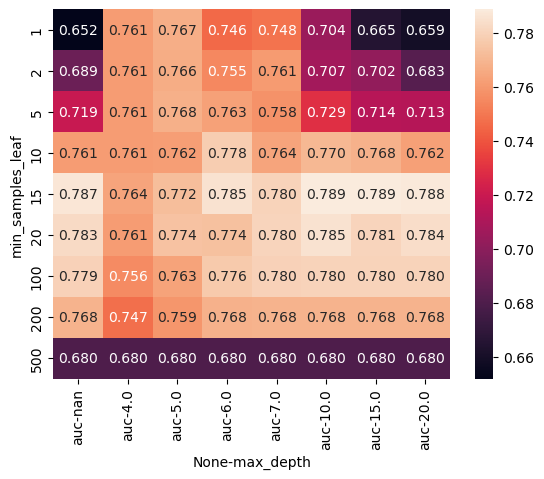

In [548]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')
plt.show()

In [549]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Note that we only searched depths 4-6 for the second parameter. On a large dataset it would be too slow to try every combination, so we first select max_depth and then tune the rest. On this small dataset we could afford to check more combinations - and if we did, other close pairs would show up. It's a good habit to start with a coarse search and refine it.

In [550]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- income <= 20.00
|   |   |   |   |   |--- seniority <= 1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- seniority >  1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- income >  20.00
|   |   |   |   |   |--- expenses <= 71.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- expenses >  71.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  4250.00
|   |   |   |   |--- debt <= 1600.00
|   |   |   |   |   |--- seniority <= 2.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- seniority >  2.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- debt >  1600.00
|   |   |   |   |   |--- class: 1
|   |   |--- income >  74.50
|   |   |   |--- seniority <= 5.50
|   |   |   |   |--- amount <= 1330.00
|   |   |   |   |   |--- assets <= 3326.00
|   |   |   |   |   |   |--- clas

One caution: when you scan the results, watch out for parameter values that don't make sense, like nan creeping into the grid. A combination can show a good score by accident - check that the values you pick actually control the size of the tree the way you intend.

### 06-06 Random Forest

Each model gets a random set of features
<br>
<br>
Ensemble learning is a machine learning paradigm where multiple models, often referred to as 'weak learners', are strategically combined to solve a particular computational intelligence problem. This approach frequently yields superior predictive performance compared to using a single model.

In [551]:
from sklearn.ensemble import RandomForestClassifier

In [552]:
rf = RandomForestClassifier(n_estimators=10, random_state=1) # 10 models
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [553]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [554]:
roc_auc_score(y_val, y_pred)

0.7744726453706618

In [555]:
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

In [556]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [557]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

df_scores

,n_estimators,auc
0,10,0.774473
1,20,0.803532
2,30,0.815075
3,40,0.815686
4,50,0.817082
5,60,0.816458
6,70,0.817321
7,80,0.816307
8,90,0.816824
9,100,0.817599


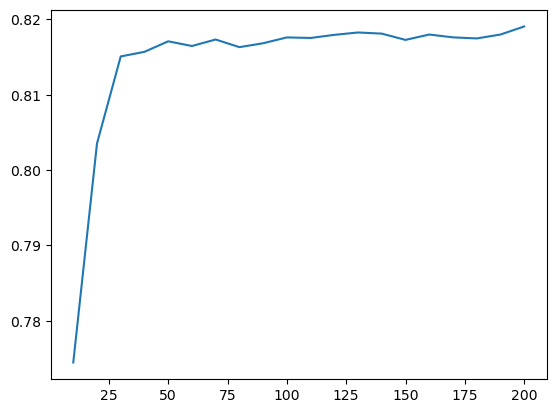

In [558]:
plt.plot(df_scores.n_estimators, df_scores.auc)
plt.show()

In [559]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [560]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878


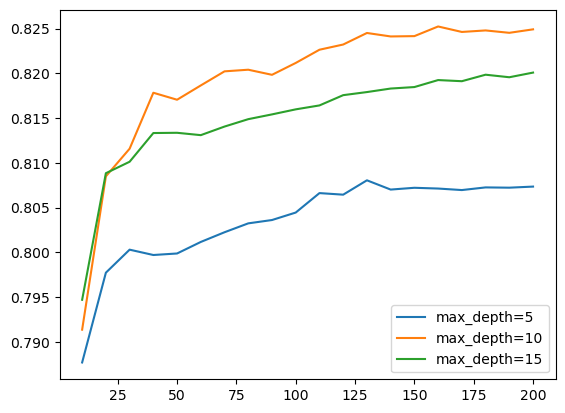

In [561]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label=f"max_depth={d}")

plt.legend()
plt.show()

In [562]:
max_depth = 10

In [563]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, 
                                    max_depth=max_depth, 
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [564]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058


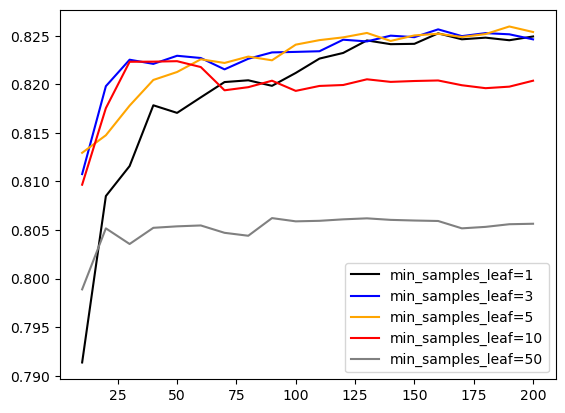

In [565]:
colours = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]

for s, col in zip(min_samples_leaf_values, colours):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, color=col, label=f"min_samples_leaf={s}")

plt.legend()
plt.show()

In [566]:
min_samples_leaf = 3

In [567]:
rf = RandomForestClassifier(n_estimators=n, 
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 06-07 Boosting

Sequentially train multiple models and each next model corrects the mistakes of the previous one (Gradient Boosting Trees)

In [568]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [569]:
import xgboost as xgb

In [570]:
# Proper data structure (dmatrix) for xgboost
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [571]:
xgb_params = {
    'eta': 0.3, # learning rate
    'max_depth': 6,
    'min_child_weight': 1, # min_samples_leaf

    'objective': 'binary:logistic', # task we are solving
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [572]:
model.predict(dval)

array([0.05866029, 0.06297418, 0.07957753, 0.12453752, 0.05471457,
       0.10543569, 0.04962284, 0.34493914, 0.62430215, 0.02429806,
       0.22594102, 0.65879387, 0.4260564 , 0.03992626, 0.22753373,
       0.63081783, 0.04498472, 0.60218894, 0.05283625, 0.23624124,
       0.063882  , 0.3727577 , 0.03212004, 0.51517475, 0.6952742 ,
       0.16815534, 0.6723981 , 0.19299386, 0.64007616, 0.03367294,
       0.80749285, 0.43654606, 0.25944966, 0.23839054, 0.05956649,
       0.02238351, 0.8702281 , 0.57544136, 0.3265658 , 0.6349808 ,
       0.07703237, 0.9244021 , 0.05706369, 0.4706856 , 0.03198274,
       0.02982934, 0.5372277 , 0.0285338 , 0.1211009 , 0.1351224 ,
       0.05263413, 0.2024241 , 0.04206237, 0.437057  , 0.473065  ,
       0.1237278 , 0.02379871, 0.24124354, 0.05047185, 0.04948641,
       0.03101486, 0.18383664, 0.05306204, 0.33299282, 0.07297256,
       0.4299966 , 0.36759862, 0.10240304, 0.13376456, 0.0878418 ,
       0.05165916, 0.21866418, 0.04464251, 0.09493332, 0.29154

In [573]:
y_pred = model.predict(dval)

In [574]:
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [575]:
# To watch the model learn
watchlist = [(dtrain, 'train'), (dval, 'dval')]

In [576]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, evals=watchlist, num_boost_round=200)

[0]	train-auc:0.86653	dval-auc:0.77999


[1]	train-auc:0.89089	dval-auc:0.79060
[2]	train-auc:0.90503	dval-auc:0.78881
[3]	train-auc:0.91573	dval-auc:0.79997
[4]	train-auc:0.92429	dval-auc:0.80367
[5]	train-auc:0.92969	dval-auc:0.80822
[6]	train-auc:0.93630	dval-auc:0.81043
[7]	train-auc:0.94073	dval-auc:0.81173
[8]	train-auc:0.94748	dval-auc:0.81328
[9]	train-auc:0.95012	dval-auc:0.81185
[10]	train-auc:0.95512	dval-auc:0.81115
[11]	train-auc:0.95661	dval-auc:0.81133
[12]	train-auc:0.95936	dval-auc:0.81433
[13]	train-auc:0.96146	dval-auc:0.81863
[14]	train-auc:0.96427	dval-auc:0.81872
[15]	train-auc:0.96767	dval-auc:0.81993
[16]	train-auc:0.96975	dval-auc:0.81863
[17]	train-auc:0.97158	dval-auc:0.82002
[18]	train-auc:0.97336	dval-auc:0.82015
[19]	train-auc:0.97499	dval-auc:0.81979
[20]	train-auc:0.97648	dval-auc:0.81877
[21]	train-auc:0.97773	dval-auc:0.81969
[22]	train-auc:0.97842	dval-auc:0.81880
[23]	train-auc:0.97902	dval-auc:0.81805
[24]	train-auc:0.98102	dval-auc:0.81686
[25]	train-auc:0.98248	dval-auc:0.81520
[26]	trai

In [577]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=200,
                    verbose_eval=5)

[0]	train-auc:0.86653	dval-auc:0.77999


[5]	train-auc:0.92969	dval-auc:0.80822
[10]	train-auc:0.95512	dval-auc:0.81115
[15]	train-auc:0.96767	dval-auc:0.81993
[20]	train-auc:0.97648	dval-auc:0.81877
[25]	train-auc:0.98248	dval-auc:0.81520
[30]	train-auc:0.98844	dval-auc:0.81613
[35]	train-auc:0.99244	dval-auc:0.81453
[40]	train-auc:0.99393	dval-auc:0.81407
[45]	train-auc:0.99568	dval-auc:0.81392
[50]	train-auc:0.99723	dval-auc:0.81276
[55]	train-auc:0.99804	dval-auc:0.81299
[60]	train-auc:0.99861	dval-auc:0.81244
[65]	train-auc:0.99916	dval-auc:0.81197
[70]	train-auc:0.99962	dval-auc:0.81243
[75]	train-auc:0.99975	dval-auc:0.81152
[80]	train-auc:0.99989	dval-auc:0.81359
[85]	train-auc:0.99993	dval-auc:0.81193
[90]	train-auc:0.99998	dval-auc:0.81038
[95]	train-auc:0.99999	dval-auc:0.80871
[100]	train-auc:0.99999	dval-auc:0.80842
[105]	train-auc:1.00000	dval-auc:0.80778
[110]	train-auc:1.00000	dval-auc:0.80764
[115]	train-auc:1.00000	dval-auc:0.80722
[120]	train-auc:1.00000	dval-auc:0.80750
[125]	train-auc:1.00000	dval-auc:0.8

In [578]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=200,
                    verbose_eval=5)

In [579]:
output.stdout

'[0]\ttrain-auc:0.86653\tdval-auc:0.77999\n[5]\ttrain-auc:0.92969\tdval-auc:0.80822\n[10]\ttrain-auc:0.95512\tdval-auc:0.81115\n[15]\ttrain-auc:0.96767\tdval-auc:0.81993\n[20]\ttrain-auc:0.97648\tdval-auc:0.81877\n[25]\ttrain-auc:0.98248\tdval-auc:0.81520\n[30]\ttrain-auc:0.98844\tdval-auc:0.81613\n[35]\ttrain-auc:0.99244\tdval-auc:0.81453\n[40]\ttrain-auc:0.99393\tdval-auc:0.81407\n[45]\ttrain-auc:0.99568\tdval-auc:0.81392\n[50]\ttrain-auc:0.99723\tdval-auc:0.81276\n[55]\ttrain-auc:0.99804\tdval-auc:0.81299\n[60]\ttrain-auc:0.99861\tdval-auc:0.81244\n[65]\ttrain-auc:0.99916\tdval-auc:0.81197\n[70]\ttrain-auc:0.99962\tdval-auc:0.81243\n[75]\ttrain-auc:0.99975\tdval-auc:0.81152\n[80]\ttrain-auc:0.99989\tdval-auc:0.81359\n[85]\ttrain-auc:0.99993\tdval-auc:0.81193\n[90]\ttrain-auc:0.99998\tdval-auc:0.81038\n[95]\ttrain-auc:0.99999\tdval-auc:0.80871\n[100]\ttrain-auc:0.99999\tdval-auc:0.80842\n[105]\ttrain-auc:1.00000\tdval-auc:0.80778\n[110]\ttrain-auc:1.00000\tdval-auc:0.80764\n[115]\ttr

In [580]:
print(output.stdout)

[0]	train-auc:0.86653	dval-auc:0.77999
[5]	train-auc:0.92969	dval-auc:0.80822
[10]	train-auc:0.95512	dval-auc:0.81115
[15]	train-auc:0.96767	dval-auc:0.81993
[20]	train-auc:0.97648	dval-auc:0.81877
[25]	train-auc:0.98248	dval-auc:0.81520
[30]	train-auc:0.98844	dval-auc:0.81613
[35]	train-auc:0.99244	dval-auc:0.81453
[40]	train-auc:0.99393	dval-auc:0.81407
[45]	train-auc:0.99568	dval-auc:0.81392
[50]	train-auc:0.99723	dval-auc:0.81276
[55]	train-auc:0.99804	dval-auc:0.81299
[60]	train-auc:0.99861	dval-auc:0.81244
[65]	train-auc:0.99916	dval-auc:0.81197
[70]	train-auc:0.99962	dval-auc:0.81243
[75]	train-auc:0.99975	dval-auc:0.81152
[80]	train-auc:0.99989	dval-auc:0.81359
[85]	train-auc:0.99993	dval-auc:0.81193
[90]	train-auc:0.99998	dval-auc:0.81038
[95]	train-auc:0.99999	dval-auc:0.80871
[100]	train-auc:0.99999	dval-auc:0.80842
[105]	train-auc:1.00000	dval-auc:0.80778
[110]	train-auc:1.00000	dval-auc:0.80764
[115]	train-auc:1.00000	dval-auc:0.80722
[120]	train-auc:1.00000	dval-auc:0.807

In [581]:
output

In [582]:
s = output.stdout

In [583]:
s.split('\n')

['[0]\ttrain-auc:0.86653\tdval-auc:0.77999',
 '[5]\ttrain-auc:0.92969\tdval-auc:0.80822',
 '[10]\ttrain-auc:0.95512\tdval-auc:0.81115',
 '[15]\ttrain-auc:0.96767\tdval-auc:0.81993',
 '[20]\ttrain-auc:0.97648\tdval-auc:0.81877',
 '[25]\ttrain-auc:0.98248\tdval-auc:0.81520',
 '[30]\ttrain-auc:0.98844\tdval-auc:0.81613',
 '[35]\ttrain-auc:0.99244\tdval-auc:0.81453',
 '[40]\ttrain-auc:0.99393\tdval-auc:0.81407',
 '[45]\ttrain-auc:0.99568\tdval-auc:0.81392',
 '[50]\ttrain-auc:0.99723\tdval-auc:0.81276',
 '[55]\ttrain-auc:0.99804\tdval-auc:0.81299',
 '[60]\ttrain-auc:0.99861\tdval-auc:0.81244',
 '[65]\ttrain-auc:0.99916\tdval-auc:0.81197',
 '[70]\ttrain-auc:0.99962\tdval-auc:0.81243',
 '[75]\ttrain-auc:0.99975\tdval-auc:0.81152',
 '[80]\ttrain-auc:0.99989\tdval-auc:0.81359',
 '[85]\ttrain-auc:0.99993\tdval-auc:0.81193',
 '[90]\ttrain-auc:0.99998\tdval-auc:0.81038',
 '[95]\ttrain-auc:0.99999\tdval-auc:0.80871',
 '[100]\ttrain-auc:0.99999\tdval-auc:0.80842',
 '[105]\ttrain-auc:1.00000\tdval-au

In [584]:
line = s.split('\n')[0]

line

'[0]\ttrain-auc:0.86653\tdval-auc:0.77999'

In [585]:
line.split('\t')

['[0]', 'train-auc:0.86653', 'dval-auc:0.77999']

In [586]:
num_iter, train_auc, val_auc = line.split('\t')

In [587]:
int(num_iter.strip('[]'))

0

In [588]:
float(train_auc.split(':')[1])

0.86653

In [589]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    
    return df_results

In [590]:
parse_xgb_output(output)

,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.92969,0.80822
2,10,0.95512,0.81115
3,15,0.96767,0.81993
4,20,0.97648,0.81877
5,25,0.98248,0.81520
6,30,0.98844,0.81613
7,35,0.99244,0.81453
8,40,0.99393,0.81407
9,45,0.99568,0.81392


In [591]:
df_score = parse_xgb_output(output)

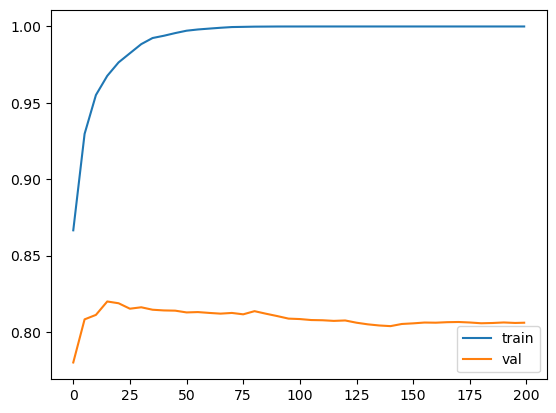

In [592]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()
plt.show()

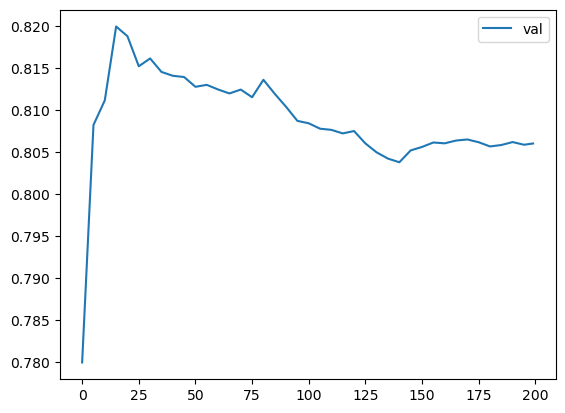

In [593]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()
plt.show()

### 06-08 XGB Tuning

In [594]:
scores = {}

In [615]:
%%capture output

xgb_params = {
    'eta': 1.0,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=200,
                    verbose_eval=5)

In [616]:
key = f"eta={xgb_params['eta']}"
scores[key] = parse_xgb_output(output)

In [617]:
scores

{'eta=0.01':     num_iter  train_auc  val_auc
 0          0    0.86653  0.77999
 1          5    0.87039  0.77827
 2         10    0.87211  0.77828
 3         15    0.87412  0.78300
 4         20    0.87621  0.78749
 5         25    0.88611  0.79587
 6         30    0.89308  0.79968
 7         35    0.89641  0.79983
 8         40    0.89874  0.79885
 9         45    0.90041  0.79691
 10        50    0.90250  0.79744
 11        55    0.90424  0.79796
 12        60    0.90575  0.79740
 13        65    0.90689  0.79641
 14        70    0.90822  0.79735
 15        75    0.90988  0.79879
 16        80    0.91112  0.79994
 17        85    0.91243  0.80142
 18        90    0.91380  0.80325
 19        95    0.91528  0.80404
 20       100    0.91656  0.80454
 21       105    0.91806  0.80506
 22       110    0.91933  0.80517
 23       115    0.92043  0.80500
 24       120    0.92177  0.80551
 25       125    0.92299  0.80615
 26       130    0.92433  0.80666
 27       135    0.92560  0.80716
 2

In [618]:
scores["eta=0.3"]

,num_iter,train_auc,val_auc
0,0,0.86653,0.77999
1,5,0.92969,0.80822
2,10,0.95512,0.81115
3,15,0.96767,0.81993
4,20,0.97648,0.81877
5,25,0.98248,0.81520
6,30,0.98844,0.81613
7,35,0.99244,0.81453
8,40,0.99393,0.81407
9,45,0.99568,0.81392


In [619]:
scores.keys()

dict_keys(['eta=0.01', 'eta=0.03', 'eta=0.05', 'eta=0.1', 'eta=0.3', 'eta=0.5', 'eta=1.0'])

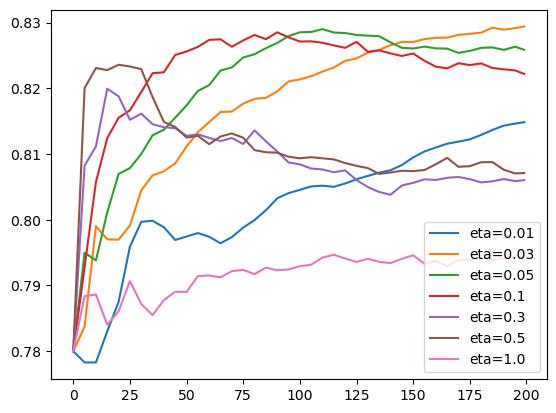

In [620]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)

plt.legend()
plt.show()

In [621]:
scores = {}

In [634]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 20,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=200,
                    verbose_eval=5)

In [635]:
key = f"max_depth={xgb_params['max_depth']}"
scores[key] = parse_xgb_output(output)

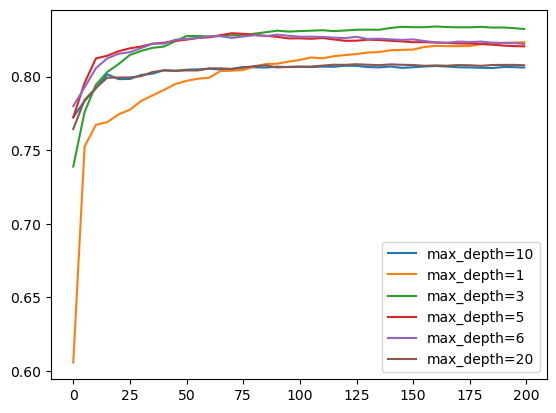

In [636]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.legend()
plt.show()

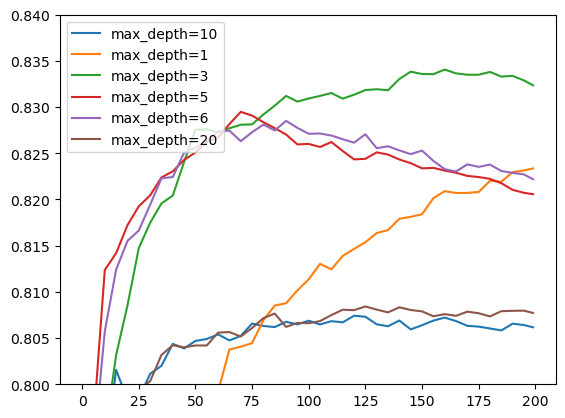

In [637]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.ylim(0.8, 0.84)
plt.legend()
plt.show()

In [638]:
scores = {}

In [649]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=200,
                    verbose_eval=5)

In [650]:
key = f"min_child_weight={xgb_params['min_child_weight']}"
scores[key] = parse_xgb_output(output)

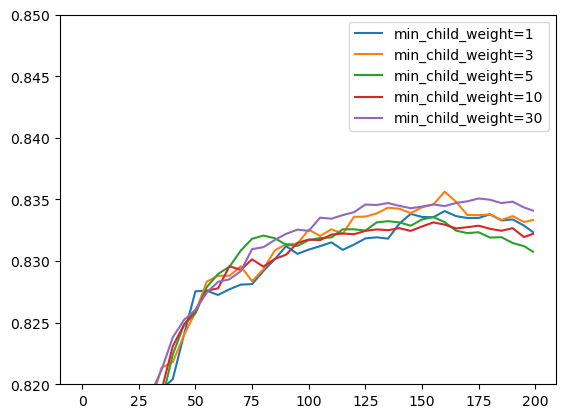

In [651]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.ylim(0.82, 0.85)
plt.legend()
plt.show()

In [653]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain, 
                    evals=watchlist, 
                    num_boost_round=175)

Other parameters worth knowing about:

- subsample - the fraction of the training data each tree sees.
- colsample_bytree - the fraction of features each tree sees, like the random feature subsets of random forest.
- lambda and alpha - the L2 and L1 regularization terms on the weights.

### 06-09 Final model

In [654]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [655]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7850802838390931

In [656]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
        
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [657]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8246258264512848

In [658]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dtrain,
                    num_boost_round=175)

In [659]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.8349852268048726

In [660]:
df_full_train = df_full_train.reset_index(drop=True)

In [661]:
y_full_train = (df_full_train.status == 'default').astype(int).values

y_full_train

array([0, 1, 0, ..., 0, 0, 1])

In [662]:
del df_full_train['status']

In [663]:
dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [664]:
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                    feature_names=list(dv.get_feature_names_out()))
                
dtest = xgb.DMatrix(X_test, feature_names=list(dv.get_feature_names_out()))

In [665]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                    dfulltrain,
                    num_boost_round=175)

In [666]:
y_pred = model.predict(dtest)

In [667]:
y_pred[:10]

array([0.2457571 , 0.29309604, 0.08425502, 0.20603578, 0.33663422,
       0.24645075, 0.00855018, 0.03036533, 0.20586072, 0.23665117],
      dtype=float32)

In [668]:
y_test

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,

In [669]:
roc_auc_score(y_test, y_pred)

0.8299814280826938

Generally, XGBoost models perform better on tabular data than other machine learning models but the downside is that these model are easy to overfit cause of the high number of hyperparameter. Therefore, XGBoost models require a lot more attention for parameters tuning to optimize them.

XGBoost can deal with NAs